In [2]:
import yfinance as yf
import pandas as pd

tickers = ["FDX", "UPS", "UNP", "NSC", "^GSPC"]
data = yf.download(tickers, start="2010-01-01", end="2026-07-16")["Close"]
data.to_csv("transport_data.csv")

[*********************100%***********************]  5 of 5 completed


In [3]:
data.head()


Ticker,FDX,NSC,UNP,UPS,^GSPC
Date,,,,,
2010-01-04,55.228424,36.090061,22.934954,32.952587,1132.989990
2010-01-05,55.949806,36.645924,23.254122,33.009220,1136.520020
2010-01-06,55.486519,36.542995,23.289194,32.765667,1137.140015
2010-01-07,54.884270,36.062618,23.082262,32.516457,1141.689941
2010-01-08,56.247608,37.304745,23.864416,34.079685,1144.979980


In [4]:
transports = data[["FDX", "UPS", "UNP", "NSC"]]
normalized = transports / transports.iloc[0] * 100
transport_index = normalized.mean(axis=1)

sp500 = data["^GSPC"]


In [5]:

transport_index.head()


Date
2010-01-04    100.000000
2010-01-05    101.102468
2010-01-06    100.674909
2010-01-07     99.654898
2010-01-08    103.171016
dtype: float64

In [6]:
transport_returns = transport_index.pct_change().dropna()
sp500_returns = sp500.pct_change().dropna()

In [7]:
transport_returns.head()


Date
2010-01-05    0.011025
2010-01-06   -0.004229
2010-01-07   -0.010132
2010-01-08    0.035283
2010-01-11    0.015333
dtype: float64

In [8]:
df = pd.DataFrame({
    "transport": transport_returns,
    "sp500": sp500_returns
}).dropna()

for lag in [1, 5, 20, 60]:  # 1 day, ~1 week, ~1 month, ~1 quarter
    df[f"sp500_lead_{lag}"] = df["sp500"].shift(-lag)
    corr = df["transport"].corr(df[f"sp500_lead_{lag}"])
    print(f"Lag {lag} days: correlation = {corr:.3f}")

Lag 1 days: correlation = -0.080
Lag 5 days: correlation = 0.031
Lag 20 days: correlation = -0.002
Lag 60 days: correlation = -0.031


Matplotlib is building the font cache; this may take a moment.


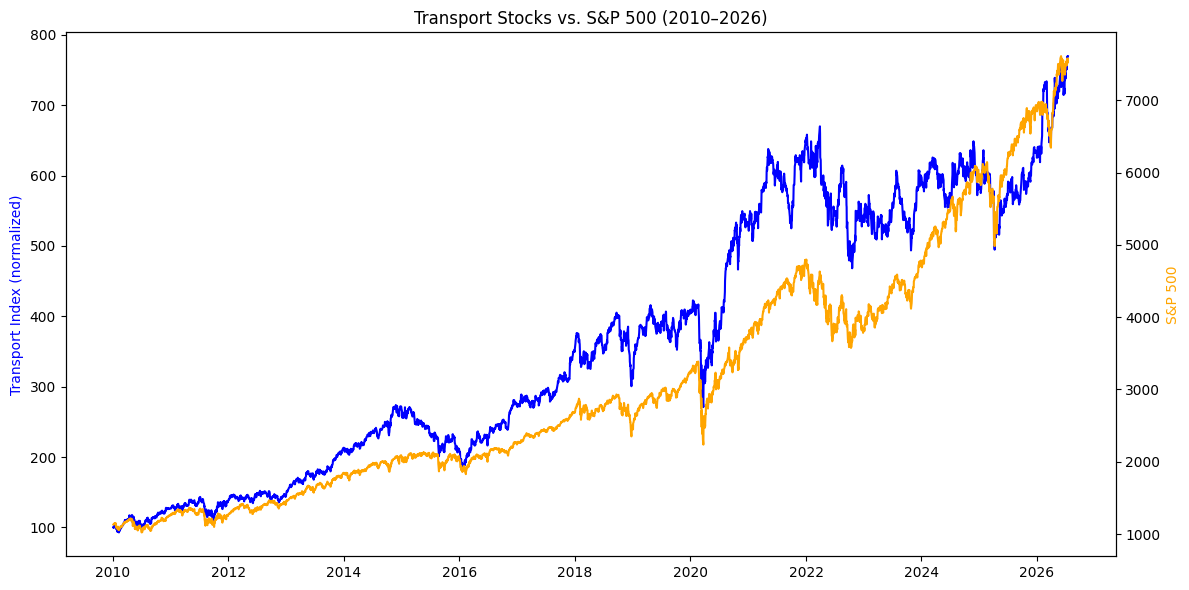

In [9]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))
ax1.plot(normalized.index, transport_index, label="Transport Index", color="blue")
ax1.set_ylabel("Transport Index (normalized)", color="blue")

ax2 = ax1.twinx()
ax2.plot(sp500.index, sp500, label="S&P 500", color="orange")
ax2.set_ylabel("S&P 500", color="orange")

plt.title("Transport Stocks vs. S&P 500 (2010–2026)")
fig.tight_layout()
plt.savefig("transport_vs_sp500.png")
plt.show()